<a href="https://colab.research.google.com/github/anshudahiya121/Medical-Insurance-Cost-Predicton/blob/main/Medical_Insurance_Cost_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv('/content/medical_costs.csv')

print(df.head())
print(df.shape)

   Age     Sex   BMI  Children Smoker     Region  Medical Cost
0   58    male  15.6         2    yes  northwest      17907.54
1   24    male  29.8         0    yes  northeast      16312.64
2   50    male  29.0         5     no  northwest       6819.21
3   35    male  34.0         1     no  southeast       5247.87
4   31  female  17.6         3    yes  southeast      17525.49
(10000, 7)


In [ ]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           10000 non-null  int64  
 1   Sex           10000 non-null  object 
 2   BMI           10000 non-null  float64
 3   Children      10000 non-null  int64  
 4   Smoker        10000 non-null  object 
 5   Region        10000 non-null  object 
 6   Medical Cost  10000 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 547.0+ KB


np.int64(0)

In [ ]:
print(df.isnull().sum())
print(df.duplicated().sum())

Age             0
Sex             0
BMI             0
Children        0
Smoker          0
Region          0
Medical Cost    0
dtype: int64
0


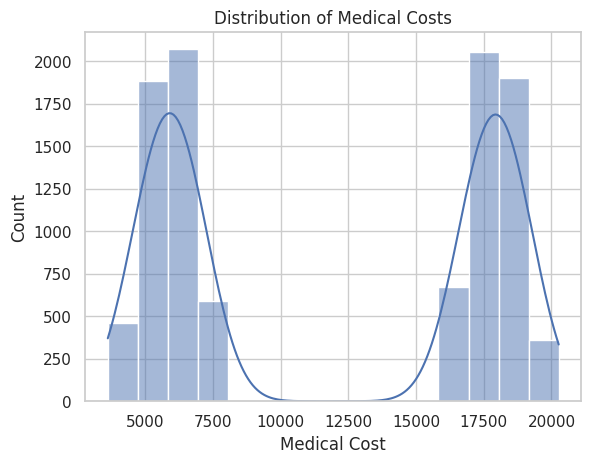

In [ ]:
sns.histplot(df['Medical Cost'], kde=True)
plt.title("Distribution of Medical Costs")
plt.show()

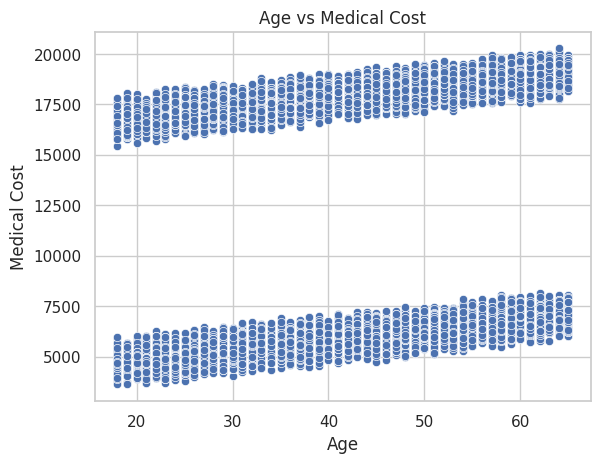

In [ ]:
sns.scatterplot(data=df, x='Age', y='Medical Cost')
plt.title("Age vs Medical Cost")
plt.show()

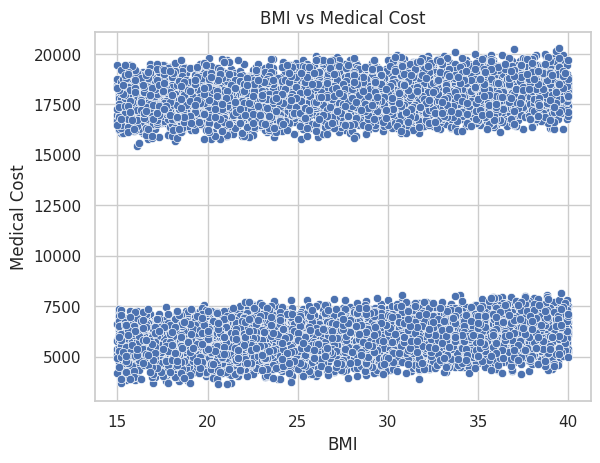

In [ ]:
sns.scatterplot(data=df, x='BMI', y='Medical Cost')
plt.title("BMI vs Medical Cost")
plt.show()

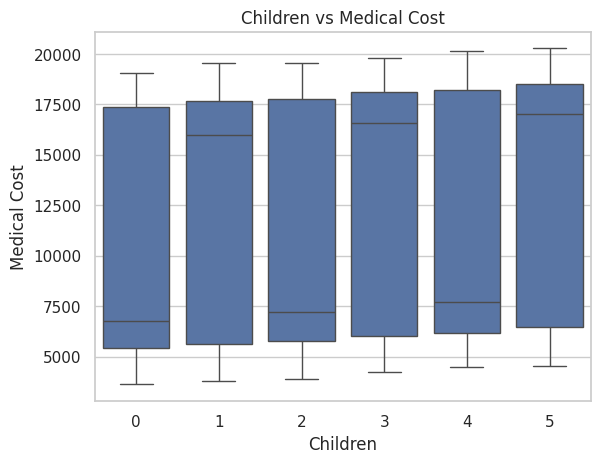

In [ ]:
sns.boxplot(data=df, x='Children', y='Medical Cost')
plt.title("Children vs Medical Cost")
plt.show()

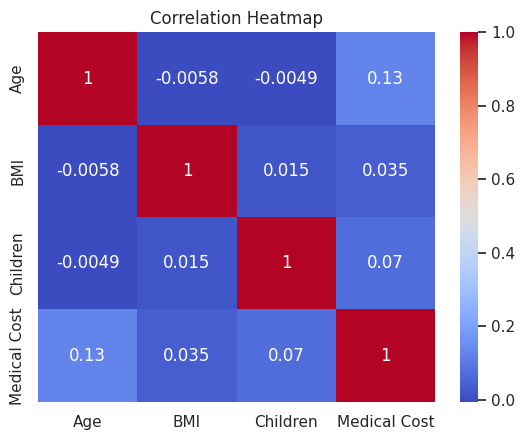

In [ ]:
num = df.select_dtypes(include='number')

sns.heatmap(num.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
target = 'Medical Cost'  # Change to actual target column

X = df.drop(columns=[target])
y = df[target]

In [ ]:
X = pd.get_dummies(X, drop_first=True, dtype=int)

print(X.head())
print(X.shape)

   Age   BMI  Children  Sex_male  Smoker_yes  Region_northwest  \
0   58  15.6         2         1           1                 1   
1   24  29.8         0         1           1                 0   
2   50  29.0         5         1           0                 1   
3   35  34.0         1         1           0                 0   
4   31  17.6         3         0           1                 0   

   Region_southeast  Region_southwest  
0                 0                 0  
1                 0                 0  
2                 0                 0  
3                 1                 0  
4                 1                 0  
(10000, 8)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(8000, 8) (2000, 8)


In [ ]:
X_simple = df[['Age']]
y = df[target]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

slr = LinearRegression()
slr.fit(X_train_s, y_train_s)

y_pred_s = slr.predict(X_test_s)

In [ ]:
print("Intercept:", slr.intercept_)
print("Coefficient:", slr.coef_[0])

Intercept: 9599.284321954616
Coefficient: 55.80584065678604


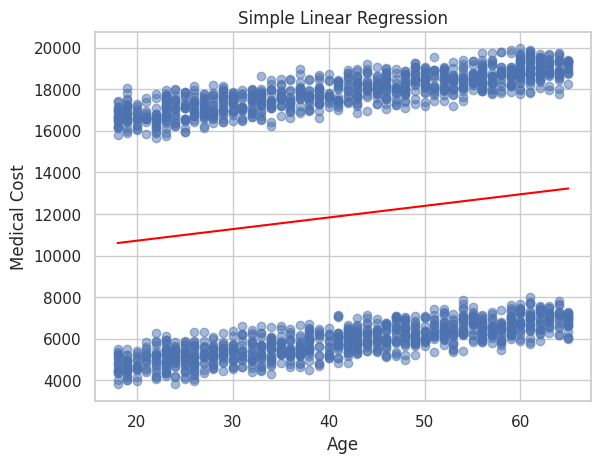

In [ ]:
plt.scatter(X_test_s['Age'], y_test_s, alpha=0.5)
plt.plot(
    X_test_s['Age'],
    y_pred_s,
    color='red'
)
plt.xlabel("Age")
plt.ylabel("Medical Cost")
plt.title("Simple Linear Regression")
plt.show()

In [ ]:
print("MAE:", mean_absolute_error(y_test_s, y_pred_s))
print("MSE:", mean_squared_error(y_test_s, y_pred_s))
print("RMSE:", np.sqrt(mean_squared_error(y_test_s, y_pred_s)))
print("R2:", r2_score(y_test_s, y_pred_s))

MAE: 5998.9517499909125
MSE: 36244657.37495785
RMSE: 6020.353592186912
R2: 0.014014031954823869


In [ ]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred_m = mlr.predict(X_test)

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred_m))
print("MSE:", mean_squared_error(y_test, y_pred_m))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_m)))
print("R2:", r2_score(y_test, y_pred_m))

MAE: 252.93862320618527
MSE: 84926.73518794552
RMSE: 291.4219195392576
R2: 0.997689685176468


In [ ]:
results = pd.DataFrame({
    'Model': ['Simple LR', 'Multiple LR'],
    'MAE': [
        mean_absolute_error(y_test_s, y_pred_s),
        mean_absolute_error(y_test, y_pred_m)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test_s, y_pred_s)),
        np.sqrt(mean_squared_error(y_test, y_pred_m))
    ],
    'R2': [
        r2_score(y_test_s, y_pred_s),
        r2_score(y_test, y_pred_m)
    ]
})

print(results)

         Model          MAE         RMSE        R2
0    Simple LR  5998.951750  6020.353592  0.014014
1  Multiple LR   252.938623   291.421920  0.997690


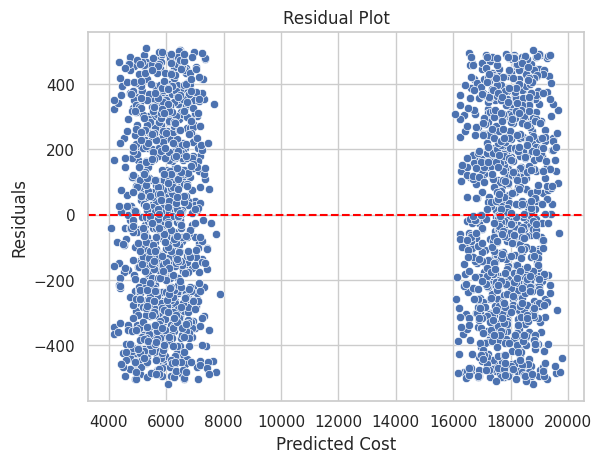

In [ ]:
residuals = y_test - y_pred_m

sns.scatterplot(x=y_pred_m, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Cost")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()